In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report


## Dataset
### Contains EEG spectral features and confusion labels collected while subjects watched educational videos

In [2]:
# Load data


# df = pd.read_csv("../data/raw/confused-eeg/EEG_data.csv") #pc
df = pd.read_csv("/kaggle/input/confused-eeg/EEG_data.csv") #kaggle

df.head()


,SubjectID,VideoID,Attention,Mediation,Raw,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,predefinedlabel,user-definedlabeln
0,0.0,0.0,56.0,43.0,278.0,301963.0,90612.0,33735.0,23991.0,27946.0,45097.0,33228.0,8293.0,0.0,0.0
1,0.0,0.0,40.0,35.0,-50.0,73787.0,28083.0,1439.0,2240.0,2746.0,3687.0,5293.0,2740.0,0.0,0.0
2,0.0,0.0,47.0,48.0,101.0,758353.0,383745.0,201999.0,62107.0,36293.0,130536.0,57243.0,25354.0,0.0,0.0
3,0.0,0.0,47.0,57.0,-5.0,2012240.0,129350.0,61236.0,17084.0,11488.0,62462.0,49960.0,33932.0,0.0,0.0
4,0.0,0.0,44.0,53.0,-8.0,1005145.0,354328.0,37102.0,88881.0,45307.0,99603.0,44790.0,29749.0,0.0,0.0


In [3]:

# sanity check
df.shape




(12811, 15)

In [4]:
df.columns


Index(['SubjectID', 'VideoID', 'Attention', 'Mediation', 'Raw', 'Delta',
       'Theta', 'Alpha1', 'Alpha2', 'Beta1', 'Beta2', 'Gamma1', 'Gamma2',
       'predefinedlabel', 'user-definedlabeln'],
      dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12811 entries, 0 to 12810
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SubjectID           12811 non-null  float64
 1   VideoID             12811 non-null  float64
 2   Attention           12811 non-null  float64
 3   Mediation           12811 non-null  float64
 4   Raw                 12811 non-null  float64
 5   Delta               12811 non-null  float64
 6   Theta               12811 non-null  float64
 7   Alpha1              12811 non-null  float64
 8   Alpha2              12811 non-null  float64
 9   Beta1               12811 non-null  float64
 10  Beta2               12811 non-null  float64
 11  Gamma1              12811 non-null  float64
 12  Gamma2              12811 non-null  float64
 13  predefinedlabel     12811 non-null  float64
 14  user-definedlabeln  12811 non-null  float64
dtypes: float64(15)
memory usage: 1.5 MB


In [6]:
df.isnull().mean().sort_values(ascending=False)

SubjectID             0.0
VideoID               0.0
Attention             0.0
Mediation             0.0
Raw                   0.0
Delta                 0.0
Theta                 0.0
Alpha1                0.0
Alpha2                0.0
Beta1                 0.0
Beta2                 0.0
Gamma1                0.0
Gamma2                0.0
predefinedlabel       0.0
user-definedlabeln    0.0
dtype: float64

In [7]:
# target variable: predefined confusion label was selected as the target variable, 
# representing whether a student was confused while watching the video.
# try user-defined label later (future work)
df['target'] = df['predefinedlabel']
df['target'].value_counts(normalize=True)


target
0.0    0.520022
1.0    0.479978
Name: proportion, dtype: float64

In [8]:
# feature selection
drop_cols = [
    'SubjectID',
    'VideoID',
    'Raw',
    'predefinedlabel',
    'user-definedlabeln'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

X = df.drop(columns='target')
y = df['target']



## EDA

### Histogram analysis

Attention and Meditation scores show irregular, multimodal distributions with large spikes at zero, suggesting non-physiological artifacts or missing-value encodings. Given their proprietary nature and uncertain derivation, these features were excluded from modeling.

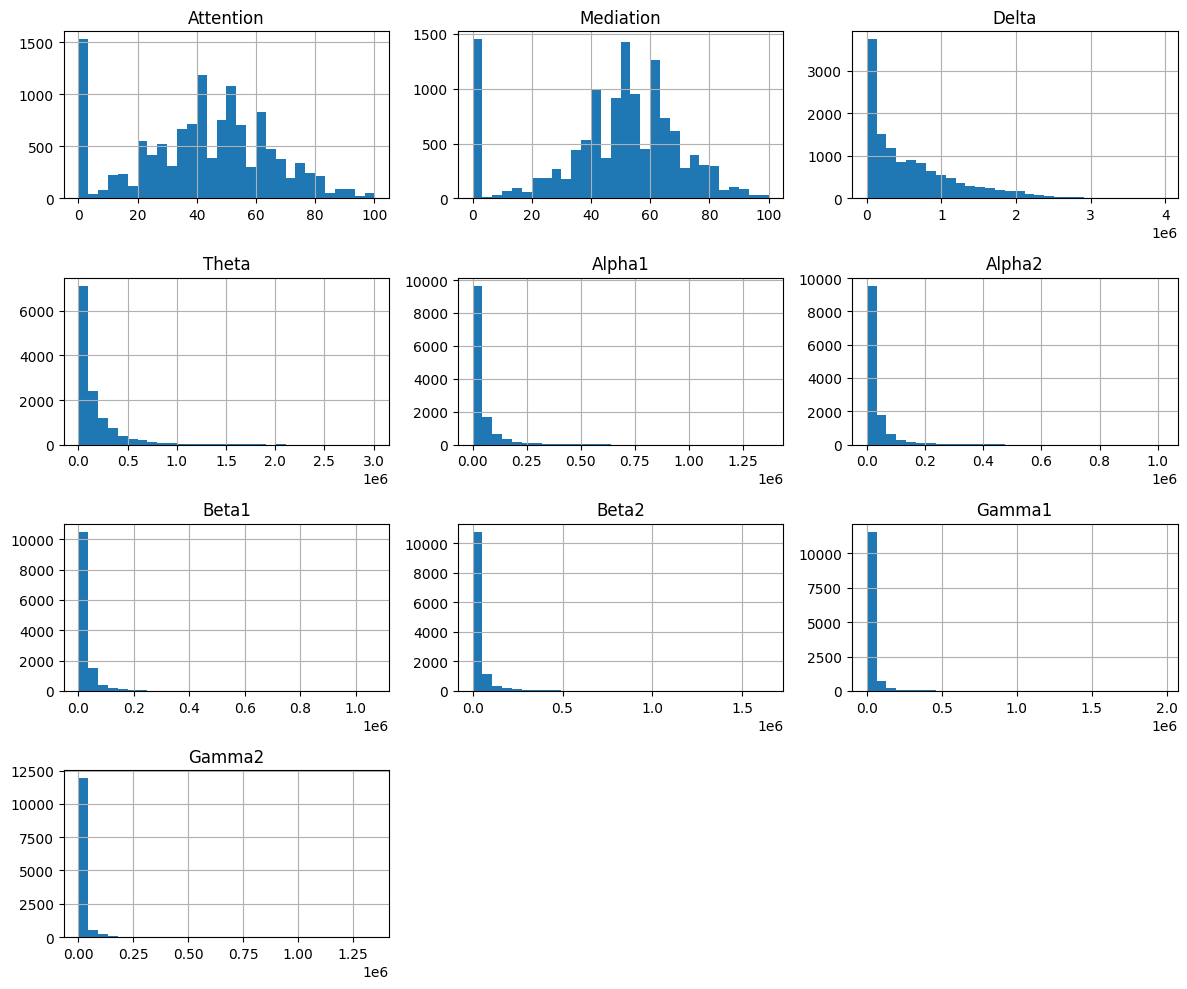

In [9]:
# Feature distributions
X.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

### Correlation heatmap
Strong correlations within frequency ranges
- Alpha1 - Alpha2
- Beta2 - Gamma1 - Gamma2
- Theta correlated with Alpha/Beta

We can say that some of these could be reduandant features and that they share physiological sources. Also some expected spectral leakage.


Strongly correlated between Attention and Meditation
- Attention and Meditation weakly negatively correlated with EEG bands.
- We can drop those columns

A logistic regression model which evaluates collinearity may not be the best fit,
Trees model may give better results by using those  interactions



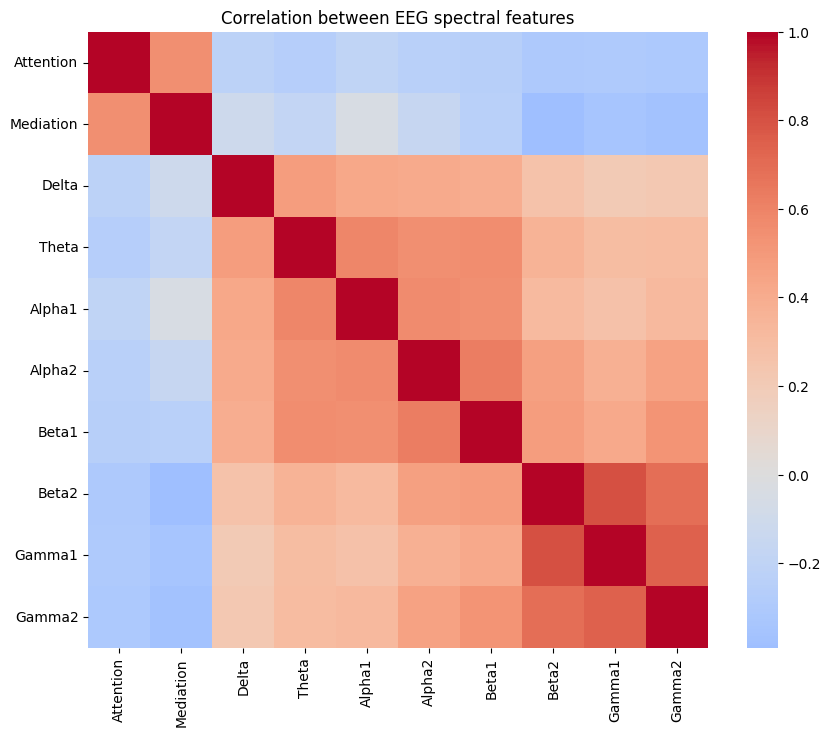

In [10]:
# correlation analysis

plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), cmap='coolwarm', center=0)
plt.title("Correlation between EEG spectral features")
plt.show()


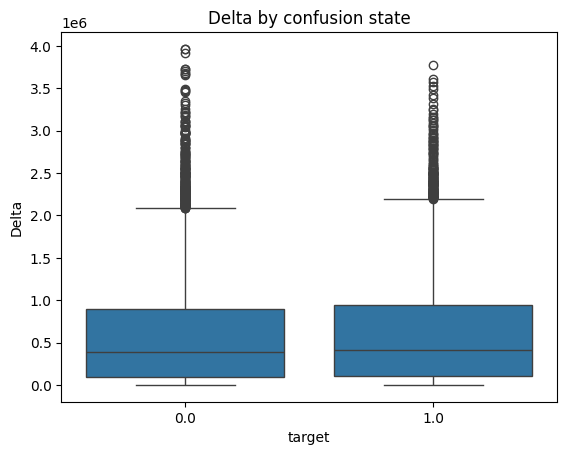

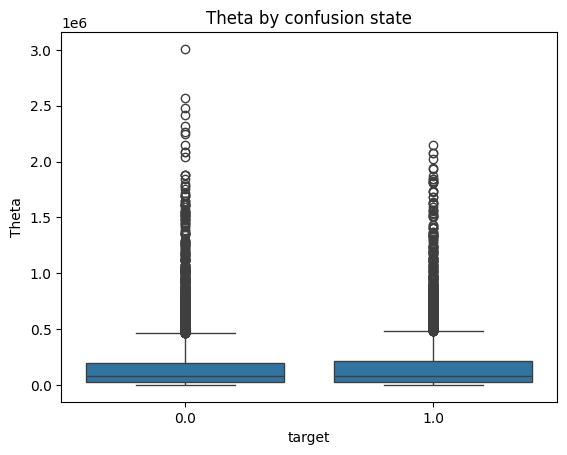

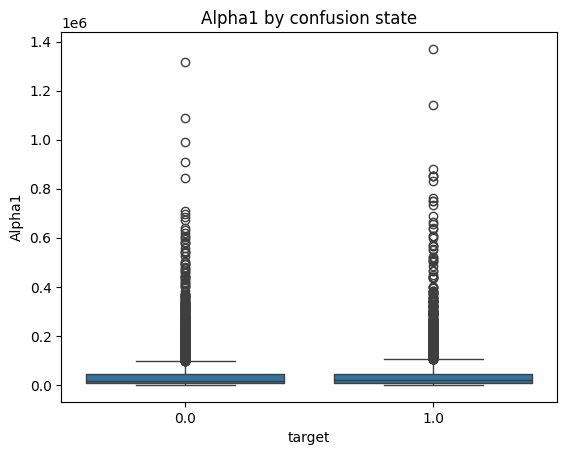

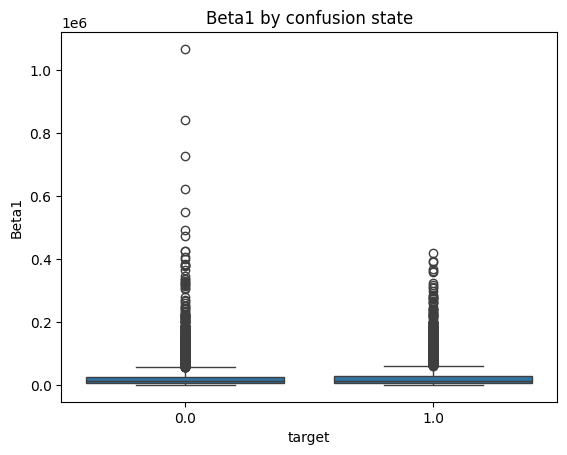

In [11]:
# confusion vs egg bands
for col in ['Delta', 'Theta', 'Alpha1', 'Beta1']:
    sns.boxplot(x=y, y=X[col])
    plt.title(f"{col} by confusion state")
    plt.show()


Log transformation will be tried based on EDA

In [12]:
eeg_cols = [
    'Delta', 'Theta', 'Alpha1', 'Alpha2',
    'Beta1', 'Beta2', 'Gamma1', 'Gamma2'
]

for col in eeg_cols:
    X[col] = np.log1p(df[col])


In [13]:
# baseline model

# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Baseline Model: Logistic Regression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred_proba)

print( "roc_auc: ", roc_auc)


roc_auc:  0.5670039461084783


roc_auc is 0.57, which could be considered weak. To improve, we can drop “Attention” and “Meditation”, since they are proprietary summary scores and often add noise


In [14]:
drop_extra = ['Attention', 'Mediation']
X = X.drop(columns=[c for c in drop_extra if c in X.columns])


In [15]:
# baseline model

# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Baseline Model: Logistic Regression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred_proba)

print( "roc_auc: ", roc_auc)


roc_auc:  0.5691904683487945


Again, roc_auc omly improves slightv which is expected as this dataset would benefit more from a random forest model

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred)

print( "RF roc_auc: ", roc_auc)


RF roc_auc:  0.592571923468672


Exploratory data analysis shows that EEG spectral power features have highly right-skewed, heavy-tailed distributions spanning several orders of magnitude, which is typical for single-channel EEG recordings. Attention and Meditation metrics showed irregular distributions with large zero-value spikes, likely reflecting proprietary preprocessing or signal dropouts, and were therefore excluded. The substantial overlap between distributions across confusion states suggests that confusion is not strongly separable using univariate linear decision boundaries, motivating the use of feature transformations and non-linear models.